# TF-IDF + Embeddings de frase
Carga `preguntas.xlsx`, limpia stopwords (EN + ES), aplica TF-IDF y genera embeddings configurables con la variable `EMBEDDING_MODEL`.

In [1]:
import pandas as pd
import nltk
import torch
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords", quiet=True)

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>


False

In [2]:
# ── Selección de modelo de embeddings ───────────────────────────────────────
# Opciones:
#   "minilm"   → all-MiniLM-L6-v2      (384 dims, sentence embeddings, muy rápido) ✅ recomendado
#   "mpnet"    → all-mpnet-base-v2      (768 dims, mejor calidad, moderado)
#   "deberta"  → microsoft/deberta-v3-base (768 dims, token CLS, lento)

EMBEDDING_MODEL = "minilm"

## 1. Carga de datos

In [3]:
df = pd.read_excel("preguntas.xlsx")
df.columns = df.columns.str.strip()
df.head()

,cod,texto,categoria_original,carpeta,nombre_carpeta,subcarpeta
0,1.0,Briefly comment on relevant information about ...,1,5,1 - santander,1 - santander
1,2.0,Bank Background: Describe your global/regional...,1,5,1 - santander,1 - santander
2,3.0,Bank Presence in the Region,1,5,1 - santander,1 - santander
3,4.0,How long has the bank been operating in each c...,1,5,1 - santander,1 - santander
4,5.0,The main business areas the bank is involved w...,1,5,1 - santander,1 - santander


## 2. TF-IDF con eliminación de stopwords (EN + ES)

In [ ]:
stop_en = set(stopwords.words("english"))
stop_es = set(stopwords.words("spanish"))
all_stops = stop_en | stop_es

vectorizer = TfidfVectorizer(stop_words=list(all_stops), lowercase=True)
tfidf_matrix = vectorizer.fit_transform(df["texto"].fillna(""))
feature_names = vectorizer.get_feature_names_out()

def top_terms(row_idx, top_n=10):
    row = tfidf_matrix[row_idx]
    coo = row.tocoo()
    pairs = sorted(zip(coo.col, coo.data), key=lambda x: -x[1])[:top_n]
    return {feature_names[col]: round(score, 4) for col, score in pairs}

df["TF"] = [top_terms(i) for i in range(len(df))]
df[["cod", "texto", "categoria_original","carpeta","nombre_carpeta","TF","subcarpeta"]].head()

,cod,texto,categoria_original,carpeta,nombre_carpeta,TF
0,1.0,Briefly comment on relevant information about ...,1,5,1 - santander,"{'relevant': 0.329, 'mentioned': 0.329, 'marke..."
1,2.0,Bank Background: Describe your global/regional...,1,5,1 - santander,"{'years': 0.4167, 'bank': 0.2333, 'background'..."
2,3.0,Bank Presence in the Region,1,5,1 - santander,"{'region': 0.7269, 'presence': 0.6204, 'bank':..."
3,4.0,How long has the bank been operating in each c...,1,5,1 - santander,"{'plans': 0.5173, 'operating': 0.4474, 'long':..."
4,5.0,The main business areas the bank is involved w...,1,5,1 - santander,"{'main': 0.4964, 'areas': 0.4294, 'involved': ..."


## 3. Generación de embeddings

In [6]:
if EMBEDDING_MODEL == "deberta":
    from transformers import DebertaV2Tokenizer, DebertaV2Model
    _tokenizer = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-base")
    _model = DebertaV2Model.from_pretrained("microsoft/deberta-v3-base")
    _model.eval()
    def get_embedding(text):
        inputs = _tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = _model(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().numpy().tolist()
else:
    from sentence_transformers import SentenceTransformer
    _model_id = {"minilm": "all-MiniLM-L6-v2", "mpnet": "all-mpnet-base-v2"}[EMBEDDING_MODEL]
    _st_model = SentenceTransformer(_model_id)
    def get_embedding(text):
        return _st_model.encode(text, show_progress_bar=False).tolist()

print(f"Generando embeddings [{EMBEDDING_MODEL}]...")
df["embedding"] = df["texto"].fillna("").apply(get_embedding)
print(f"Listo. Dimensión: {len(df['embedding'].iloc[0])}")

/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generando embeddings [minilm]...
Listo. Dimensión: 384


## 4. Resultado parcial

In [7]:
df.head()

,cod,texto,categoria_original,carpeta,nombre_carpeta,subcarpeta,TF,embedding
0,1.0,Briefly comment on relevant information about ...,1,5,1 - santander,1 - santander,"{'relevant': 0.329, 'mentioned': 0.329, 'marke...","[0.05125663802027702, -0.0033077255357056856, ..."
1,2.0,Bank Background: Describe your global/regional...,1,5,1 - santander,1 - santander,"{'years': 0.4167, 'bank': 0.2333, 'background'...","[0.06418301165103912, 0.020272769033908844, -0..."
2,3.0,Bank Presence in the Region,1,5,1 - santander,1 - santander,"{'region': 0.7269, 'presence': 0.6204, 'bank':...","[0.11038175970315933, -0.011206133291125298, -..."
3,4.0,How long has the bank been operating in each c...,1,5,1 - santander,1 - santander,"{'plans': 0.5173, 'operating': 0.4474, 'long':...","[0.03013380616903305, -0.037552010267972946, -..."
4,5.0,The main business areas the bank is involved w...,1,5,1 - santander,1 - santander,"{'main': 0.4964, 'areas': 0.4294, 'involved': ...","[0.12210996448993683, -0.06907134503126144, -0..."


## 5. Clustering — preparación de la matriz de embeddings

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = np.array(df["embedding"].tolist())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
print(f"Explained variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")

Explained variance (2 components): 11.73%


## 6. KMeans — Elbow y Silhouette

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/javierz

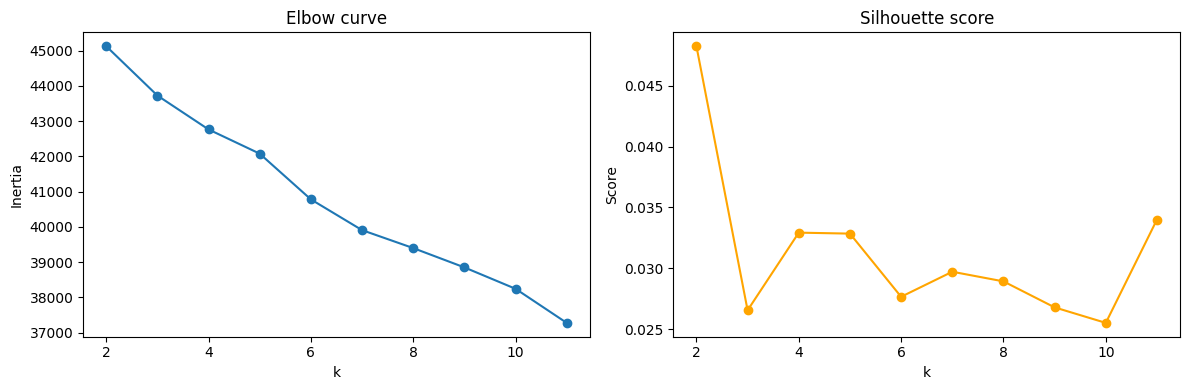

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/javierzazo/Library/CloudStorage/OneDrive-Personal/Programacion/entornos/python311_neo_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


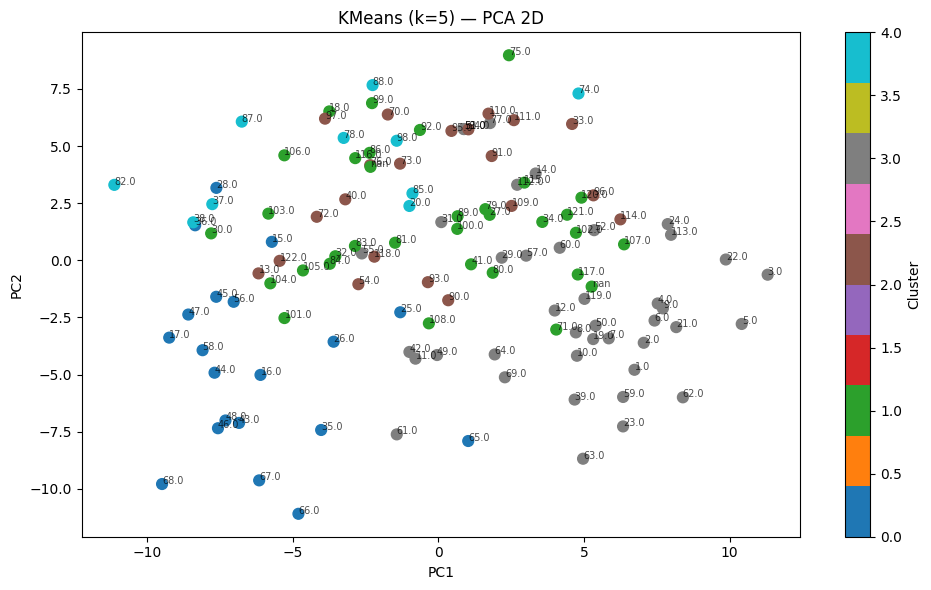

,cod,texto,cluster_kmeans
57,58.0,Describe the responsibilities of each represen...,0
42,43.0,What resources (function and number) from Disn...,0
27,28.0,Do you provide AI-based invoice and receivable...,0
43,44.0,Please describe your post implementation servi...,0
25,26.0,Do you provide AI-based liquidity forecasting ...,0
...,...,...,...
19,20.0,Confirm your ability to provide monthly domest...,4
97,98.0,Can users add custom fields to initiated payme...,4
36,37.0,How often are your disaster recovery procedure...,4
84,85.0,Can reporting be fully configured by ADM? Such...,4


In [10]:
# Elige k según las gráficas anteriores (por defecto 5)
K = 5
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster_kmeans"], cmap="tab10", s=60)
for i, row in df.iterrows():
    plt.annotate(str(row["cod"]), (X_2d[i, 0], X_2d[i, 1]), fontsize=7, alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.title(f"KMeans (k={K}) — PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

df[["cod", "texto", "cluster_kmeans"]].sort_values("cluster_kmeans")

## 7. Clustering jerárquico (Agglomerative)

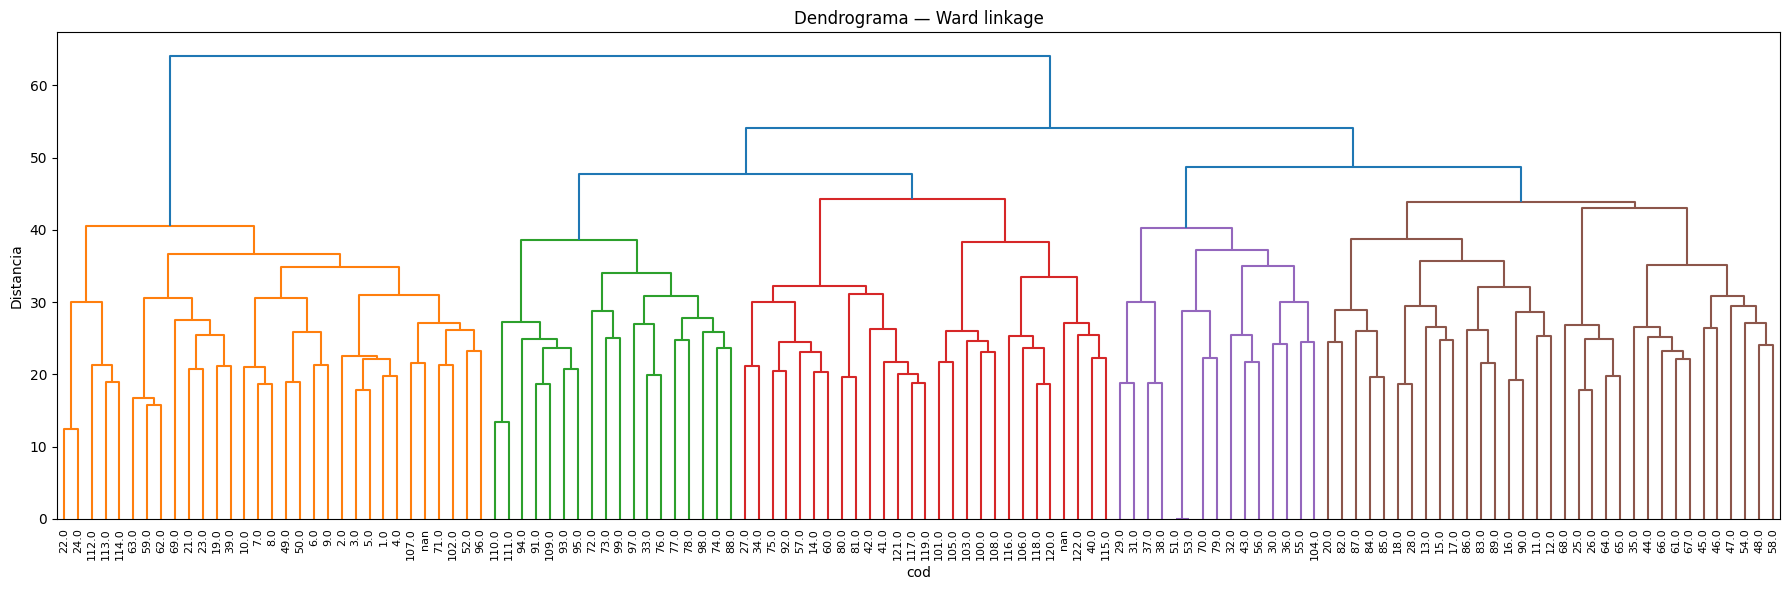

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(18, 6))
dendrogram(
    Z,
    labels=df["cod"].astype(str).tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2]),
)
plt.title("Dendrograma — Ward linkage")
plt.xlabel("cod")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

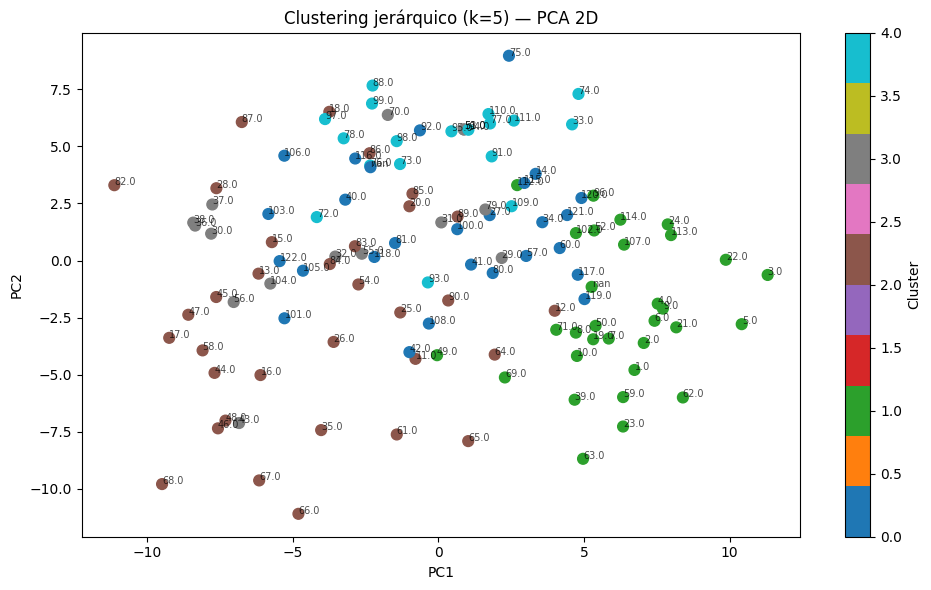

,cod,texto,cluster_kmeans,cluster_hierarchical
123,NaN,"Are wet signatures mandatory, or are digital s...",1,0
41,42.0,Based on your bank's experience from completio...,3,0
56,57.0,What is the bank's process for Customer Servic...,3,0
33,34.0,Share with us highlights of your bank's fraud ...,1,0
59,60.0,How does your bank provide regulatory updates ...,3,0
...,...,...,...,...
94,95.0,What alternative solutions do you offer for no...,2,4
96,97.0,What is your process for cancelling or amendin...,2,4
97,98.0,Can users add custom fields to initiated payme...,4,4
98,99.0,Does your payments portal support STP authoriz...,1,4


In [12]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
df["cluster_hierarchical"] = agg.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster_hierarchical"], cmap="tab10", s=60)
for i, row in df.iterrows():
    plt.annotate(str(row["cod"]), (X_2d[i, 0], X_2d[i, 1]), fontsize=7, alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.title(f"Clustering jerárquico (k={K}) — PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

df[["cod", "texto", "cluster_kmeans", "cluster_hierarchical"]].sort_values("cluster_hierarchical")

## 8. topic con LDA

In [13]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df["texto"].fillna(""))

lda = LatentDirichletAllocation(n_components=5)
lda.fit(X)

# visualizar los topics
 
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx}:")
    print([feature_names[i] for i in topic.argsort()[-10:]])

topic_distribution = lda.transform(X)

df["topic"] = topic_distribution.argmax(axis=1)
df.head()


Topic 0:
['does', 'cash', 'available', 'solutions', 'reporting', 'requirements', 'payment', 'ai', 'provide', 'bank']

Topic 1:
['local', 'scope', 'offer', 'country', 'does', 'test', 'process', 'customer', 'payment', 'bank']

Topic 2:
['solution', 'management', 'cash', 'process', 'border', 'cross', 'information', 'payments', 'support', 'bank']

Topic 3:
['available', 'platform', 'provide', 'accounts', 'implementation', 'offer', 'support', 'account', 'does', 'bank']

Topic 4:
['available', 'hours', 'time', 'standard', 'account', 'customer', 'specify', 'provide', 'bank', 'service']


,cod,texto,categoria_original,carpeta,nombre_carpeta,subcarpeta,TF,embedding,cluster_kmeans,cluster_hierarchical,topic
0,1.0,Briefly comment on relevant information about ...,1,5,1 - santander,1 - santander,"{'relevant': 0.329, 'mentioned': 0.329, 'marke...","[0.05125663802027702, -0.0033077255357056856, ...",3,1,2
1,2.0,Bank Background: Describe your global/regional...,1,5,1 - santander,1 - santander,"{'years': 0.4167, 'bank': 0.2333, 'background'...","[0.06418301165103912, 0.020272769033908844, -0...",3,1,1
2,3.0,Bank Presence in the Region,1,5,1 - santander,1 - santander,"{'region': 0.7269, 'presence': 0.6204, 'bank':...","[0.11038175970315933, -0.011206133291125298, -...",3,1,1
3,4.0,How long has the bank been operating in each c...,1,5,1 - santander,1 - santander,"{'plans': 0.5173, 'operating': 0.4474, 'long':...","[0.03013380616903305, -0.037552010267972946, -...",3,1,0
4,5.0,The main business areas the bank is involved w...,1,5,1 - santander,1 - santander,"{'main': 0.4964, 'areas': 0.4294, 'involved': ...","[0.12210996448993683, -0.06907134503126144, -0...",3,1,1


## 9. BERTopic — Topic Modeling con embeddings CLS

In [14]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

docs = df["texto"].fillna("").tolist()
embeddings = np.array(df["embedding"].tolist())

n = len(docs)
n_neighbors = min(5, n - 1)
min_cluster_size = max(2, n // 10)

umap_model = UMAP(
    n_neighbors=n_neighbors,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

vectorizer_model = CountVectorizer(
    stop_words=list(all_stops),
    min_df=1,
    ngram_range=(1, 2),
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True,
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
df["topic_bertopic"] = topics
df["topic_prob"] = probs

print(f"\nTopics encontrados: {len(set(topics)) - (1 if -1 in topics else 0)} (excluyendo outliers -1)")
topic_model.get_topic_info()

2026-03-31 19:44:47,686 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 19:44:50,165 - BERTopic - Dimensionality - Completed ✓
2026-03-31 19:44:50,166 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 19:44:50,171 - BERTopic - Cluster - Completed ✓
2026-03-31 19:44:50,173 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 19:44:50,180 - BERTopic - Representation - Completed ✓



Topics encontrados: 7 (excluyendo outliers -1)


,Topic,Count,Name,Representation,Representative_Docs
0,0,29,0_payments_payment_ebs_kyc,"[payments, payment, ebs, kyc, eg, solutions, a...",[Can users add custom fields to initiated paym...
1,1,18,1_bank_list_country_rates,"[bank, list, country, rates, please list, pres...",[If the country allows cross-border cash pooli...
2,2,17,2_describe_cash_cash management_management,"[describe, cash, cash management, management, ...",[Please comment on long term strategy of your ...
3,3,17,3_information_receivable_reporting_details,"[information, receivable, reporting, details, ...",[Please outline how your solution can support ...
4,4,17,4_please_standard_disney_please specify,"[please, standard, disney, please specify, cus...",[Does your bank have standard response times f...
5,5,13,5_customer_service_banks_customer service,"[customer, service, banks, customer service, p...",[Please describe your bank's customer service ...
6,6,13,6_test_disaster_plan_documentation,"[test, disaster, plan, documentation, support,...",[Based on your bank's experience from completi...


In [15]:
# Visualización: barchart de palabras clave por topic
topic_model.visualize_barchart(top_n_topics=min(10, len(topic_model.get_topic_info()) ))

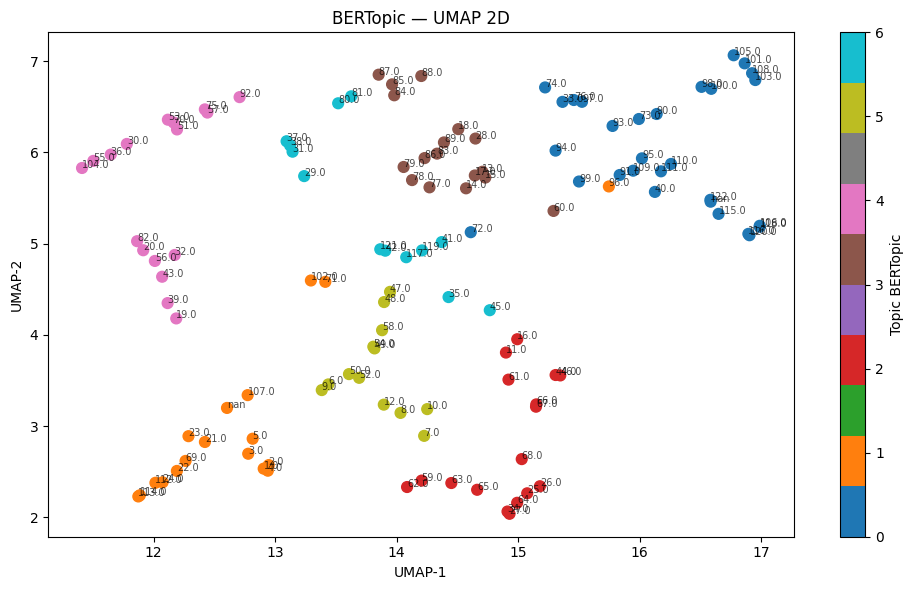

,cod,texto,topic_bertopic,topic_prob
123,NaN,"Are wet signatures mandatory, or are digital s...",0,0.481195
71,72.0,Identify your supported connectivity channels ...,0,1.000000
32,33.0,How does your bank identify duplicate payments...,0,1.000000
72,73.0,What XML versions are supported for all paymen...,0,1.000000
73,74.0,Can your bank process mixed payment files cont...,0,1.000000
...,...,...,...,...
30,31.0,Is a formal contingency plan in place in the e...,6,1.000000
28,29.0,"Under contingency scenarios, indicate the proc...",6,1.000000
79,80.0,"What TEST environments are available, and do t...",6,1.000000
44,45.0,In what languages are user manuals available?,6,1.000000


In [16]:
# Mapa 2D de documentos coloreados por topic
umap_2d = UMAP(n_neighbors=n_neighbors, n_components=2, min_dist=0.0, metric="cosine", random_state=42)
X_bert_2d = umap_2d.fit_transform(embeddings)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_bert_2d[:, 0], X_bert_2d[:, 1], c=df["topic_bertopic"], cmap="tab10", s=60)
for i, row in df.iterrows():
    plt.annotate(str(row["cod"]), (X_bert_2d[i, 0], X_bert_2d[i, 1]), fontsize=7, alpha=0.7)
plt.colorbar(scatter, label="Topic BERTopic")
plt.title("BERTopic — UMAP 2D")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

df[["cod", "texto", "topic_bertopic", "topic_prob"]].sort_values("topic_bertopic")

## Salvar en disco

In [ ]:
df.to_excel("resultados.xlsx", index=False)
print("resultados.xlsx")

Guardado en preguntas_tfidf.xlsx


In [17]:
df.head()

,cod,texto,categoria_original,carpeta,nombre_carpeta,subcarpeta,TF,embedding,cluster_kmeans,cluster_hierarchical,topic,topic_bertopic,topic_prob
0,1.0,Briefly comment on relevant information about ...,1,5,1 - santander,1 - santander,"{'relevant': 0.329, 'mentioned': 0.329, 'marke...","[0.05125663802027702, -0.0033077255357056856, ...",3,1,2,1,1.0
1,2.0,Bank Background: Describe your global/regional...,1,5,1 - santander,1 - santander,"{'years': 0.4167, 'bank': 0.2333, 'background'...","[0.06418301165103912, 0.020272769033908844, -0...",3,1,1,1,1.0
2,3.0,Bank Presence in the Region,1,5,1 - santander,1 - santander,"{'region': 0.7269, 'presence': 0.6204, 'bank':...","[0.11038175970315933, -0.011206133291125298, -...",3,1,1,1,1.0
3,4.0,How long has the bank been operating in each c...,1,5,1 - santander,1 - santander,"{'plans': 0.5173, 'operating': 0.4474, 'long':...","[0.03013380616903305, -0.037552010267972946, -...",3,1,0,1,1.0
4,5.0,The main business areas the bank is involved w...,1,5,1 - santander,1 - santander,"{'main': 0.4964, 'areas': 0.4294, 'involved': ...","[0.12210996448993683, -0.06907134503126144, -0...",3,1,1,1,1.0
